# IAC 2026 — Week 2a: Real-Weather Multi-Object GRU Development

**Paper:** *Hybrid AI-Augmented Framework for High-Fidelity Tracking of Non-Cooperative Objects*  
**Paper ID:** IAC-26,A6,9,8,x109530

## Scientific objective

Week 1b established a physically motivated benchmark:

**observed historical F10.7 + Ap → NRLMSISE-00 density → physical atmospheric drag → tuned Cartesian EKF**

This notebook asks the next clean question:

> **Can an RTN-frame GRU residual corrector improve a properly tuned EKF when it is trained across many Starlink orbital geometries, multiple observed space-weather histories, and sparse-observation regimes?**

## Development protocol

### Orbital split — inherited and frozen from Week 1b
- **18 TRAIN objects**
- **6 VALIDATION objects**
- **6 TEST objects**

The six TEST objects remain completely untouched in this notebook.

### Space-weather split
To avoid training and validating on the same weather histories:

- **TRAIN weather:** 2021–2023
- **VALIDATION weather:** 2024
- **FINAL TEST weather:** 2025 — **not accessed in this notebook**

The notebook objectively selects real quiet / moderate / storm days using Ap statistics only — never orbit-tracking performance.

### Observation regimes used for model development
For every object/weather trajectory:
1. 10-minute nominal observations
2. 20-minute nominal observations
3. 10-minute observations with a fixed 4-hour blackout from hour 10 to 14

The same truth trajectory, initial-error realization, and underlying measurement-noise field are shared across the three schedules for each object/weather case.

### Dynamics
Truth:
- two-body gravity
- J2
- NRLMSISE-00 density
- physical atmospheric drag
- observed historical F10.7 and Ap forcing
- representative Starlink aerodynamic parameters

EKF:
- two-body + J2
- tuned Week-1b fixed process noise
- no atmospheric drag model

### GRU
The learning architecture remains deliberately small:
- RTN residual target
- one GRU layer
- 16 hidden units
- dropout 0.20
- 60-minute input history sampled every 5 minutes
- early stopping on **VALIDATION objects/weather only**

## Important limitations

This remains a controlled historical-replay experiment:
- 2026 Starlink orbital geometries are exposed to historical environmental forcing;
- the Cartesian position measurement model is a sensor abstraction;
- `Cd=2.2` and `A/m=0.02 m²/kg` are representative assumptions;
- atmospheric density is evaluated along the nominal orbital fly-through and interpolated into the truth propagation.

These limitations should remain explicit in the paper.

In [ ]:
# S0 — Colab dependencies

!pip -q install "sgp4>=2.25" "pymsis>=0.12.0" "astropy>=6.0" scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00


In [ ]:
# S1 — Imports, device, reproducibility, folders

import json
import math
import shutil
import zipfile
import warnings
from copy import deepcopy
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t as student_t
from sklearn.preprocessing import StandardScaler

from sgp4.api import Satrec, SGP4_ERRORS
from sgp4 import omm

import pymsis
from pymsis.utils import download_f107_ap, get_f107_ap

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.coordinates import (
    TEME,
    ITRS,
    EarthLocation,
    CartesianRepresentation,
)

import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 20260824
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

ROOT_DIR = Path("/content/IAC2026_FINAL_WEEK2A")
SOURCE_DIR = ROOT_DIR / "week1b_source"
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"
MODEL_DIR = ROOT_DIR / "model"

for p in [
    ROOT_DIR,
    SOURCE_DIR,
    DATA_DIR,
    OUTPUT_DIR,
    MODEL_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11

print("✅ Week 2a initialized")
print("   device:", DEVICE)
print("   root:", ROOT_DIR)

✅ Week 2a initialized
   device: cpu
   root: /content/IAC2026_FINAL_WEEK2A


# 1 — Load the exact successful Week-1b bundle

Upload:

`IAC2026_FINAL_WEEK1B_bundle.zip`

No new Starlink catalog is downloaded. The object population and split remain exactly those established in Week 1b.

In [ ]:
# A0 — Upload/extract Week-1b bundle

EXPECTED_ZIP = Path(
    "/content/IAC2026_FINAL_WEEK1B_bundle.zip"
)

if not EXPECTED_ZIP.exists():

    print(
        "Please upload IAC2026_FINAL_WEEK1B_bundle.zip"
    )

    from google.colab import files

    uploaded = files.upload()

    zip_names = [
        name
        for name in uploaded
        if name.lower().endswith(".zip")
    ]

    if len(zip_names) != 1:
        raise RuntimeError(
            "Please upload exactly one Week-1b ZIP."
        )

    uploaded_path = (
        Path("/content")
        / zip_names[0]
    )

    if uploaded_path != EXPECTED_ZIP:
        shutil.copy2(
            uploaded_path,
            EXPECTED_ZIP,
        )

with zipfile.ZipFile(
    EXPECTED_ZIP,
    "r",
) as z:

    z.extractall(
        SOURCE_DIR
    )

print("✅ Week-1b bundle extracted")

Please upload IAC2026_FINAL_WEEK1B_bundle.zip


Saving IAC2026_FINAL_WEEK1B_bundle.zip to IAC2026_FINAL_WEEK1B_bundle.zip
✅ Week-1b bundle extracted


In [ ]:
# A1 — Locate frozen cohort, OMM snapshot, and Week-1b manifest

def find_unique_file(
    root,
    filename,
):
    matches = list(
        Path(root).rglob(
            filename
        )
    )

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {filename}; "
            f"found {len(matches)}"
        )

    return matches[0]


COHORT_PATH = find_unique_file(
    SOURCE_DIR,
    "starlink_30_object_cohort_WEEK1B.csv",
)

SNAPSHOT_PATH = find_unique_file(
    SOURCE_DIR,
    "starlink_supgp_snapshot.json",
)

WEEK1B_MANIFEST_PATH = find_unique_file(
    SOURCE_DIR,
    "week1b_reproducibility_manifest.json",
)


cohort_df = pd.read_csv(
    COHORT_PATH
)

with open(
    SNAPSHOT_PATH,
    "r",
) as f:
    starlink_records = json.load(f)

with open(
    WEEK1B_MANIFEST_PATH,
    "r",
) as f:
    week1b_manifest = json.load(f)


SIGMA_A_FINAL_DEV = float(
    week1b_manifest[
        "selected_sigma_a_km_s2"
    ]
)


assert len(cohort_df) == 30
assert (
    cohort_df["SPLIT"]
    == "TRAIN"
).sum() == 18
assert (
    cohort_df["SPLIT"]
    == "VALIDATION"
).sum() == 6
assert (
    cohort_df["SPLIT"]
    == "TEST"
).sum() == 6

print("✅ Frozen Week-1b experiment loaded")
print("   tuned sigma_a:", SIGMA_A_FINAL_DEV)
print(
    "   split:",
    cohort_df["SPLIT"]
    .value_counts()
    .to_dict(),
)

print(
    "   TEST shells:",
    sorted(
        cohort_df.loc[
            cohort_df["SPLIT"]
            == "TEST",
            "SHELL",
        ].unique()
    ),
)

✅ Frozen Week-1b experiment loaded
   tuned sigma_a: 3e-08
   split: {'TRAIN': 18, 'TEST': 6, 'VALIDATION': 6}
   TEST shells: ['43deg', '53deg', '70deg', '97deg']


In [ ]:
# A2 — Reinitialize Satrec objects from frozen OMM snapshot

latest_by_norad = {}

for rec in starlink_records:

    try:
        norad = int(
            rec["NORAD_CAT_ID"]
        )
        epoch = pd.Timestamp(
            rec["EPOCH"]
        )
    except Exception:
        continue

    if (
        norad not in latest_by_norad
        or epoch
        > pd.Timestamp(
            latest_by_norad[
                norad
            ]["EPOCH"]
        )
    ):
        latest_by_norad[
            norad
        ] = rec


satrec_by_norad = {}

for norad in (
    cohort_df[
        "NORAD_CAT_ID"
    ].astype(int)
):

    rec = latest_by_norad[
        norad
    ]

    sat = Satrec()

    omm.initialize(
        sat,
        rec,
    )

    satrec_by_norad[
        norad
    ] = sat


TRAIN_OBJECTS = (
    cohort_df[
        cohort_df["SPLIT"]
        == "TRAIN"
    ]
    .copy()
    .reset_index(drop=True)
)

VAL_OBJECTS = (
    cohort_df[
        cohort_df["SPLIT"]
        == "VALIDATION"
    ]
    .copy()
    .reset_index(drop=True)
)

TEST_OBJECT_IDS = set(
    cohort_df.loc[
        cohort_df["SPLIT"]
        == "TEST",
        "NORAD_CAT_ID",
    ].astype(int)
)


print(
    "✅ Satrec objects initialized"
)
print(
    "   TRAIN objects:",
    len(TRAIN_OBJECTS),
)
print(
    "   VALIDATION objects:",
    len(VAL_OBJECTS),
)
print(
    "   TEST objects protected:",
    len(TEST_OBJECT_IDS),
)

✅ Satrec objects initialized
   TRAIN objects: 18
   VALIDATION objects: 6
   TEST objects protected: 6


# 2 — Select multiple REAL weather histories

Selection depends **only** on historical Ap statistics.

### Training
Scan 2021-01-01 through 2023-12-31 and select:
- 2 widely separated low-activity days
- 2 widely separated median-activity days
- 2 widely separated high-activity days

### Validation
Scan calendar year 2024 and select:
- 1 quiet day
- 1 moderate day
- 1 storm day

### Final test
Calendar year **2025 is not queried in this notebook**. It is reserved for the later final-test notebook.

In [ ]:
# B0 — Ensure PyMSIS historical weather data are available

download_f107_ap()

print(
    "✅ Historical F10.7 / Ap database available"
)

/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:45: UserWarning: Downloading ap and F10.7 data from https://celestrak.org/SpaceData/SW-All.csv
  warnings.warn(f"Downloading ap and F10.7 data from {_F107_AP_URL}")


✅ Historical F10.7 / Ap database available


In [ ]:
# B1 — Weather scan helpers

def scan_weather_period(
    start_date,
    end_date,
):

    dates = np.arange(
        np.datetime64(
            start_date,
            "h",
        ),
        np.datetime64(
            end_date,
            "h",
        ),
        np.timedelta64(
            3,
            "h",
        ),
    )

    f107, f107a, aps = (
        get_f107_ap(
            dates
        )
    )

    df = pd.DataFrame({
        "datetime": pd.to_datetime(
            dates
        ),
        "f107": np.asarray(
            f107,
            dtype=float,
        ),
        "f107a": np.asarray(
            f107a,
            dtype=float,
        ),
        "daily_ap": np.asarray(
            aps[:, 0],
            dtype=float,
        ),
        "current_3h_ap": np.asarray(
            aps[:, 1],
            dtype=float,
        ),
    })

    df["date"] = (
        df["datetime"]
        .dt.floor("D")
    )

    daily = (
        df.groupby("date")
        .agg(
            mean_3h_ap=(
                "current_3h_ap",
                "mean",
            ),
            max_3h_ap=(
                "current_3h_ap",
                "max",
            ),
            mean_f107=(
                "f107",
                "mean",
            ),
        )
        .reset_index()
    )

    return daily


def choose_separated_days(
    ranked_dates,
    n,
    min_sep_days=30,
):

    chosen = []

    for value in ranked_dates:

        day = pd.Timestamp(
            value
        )

        if all(
            abs(
                (
                    day - prev
                ).days
            )
            >= min_sep_days
            for prev in chosen
        ):

            chosen.append(
                day
            )

        if len(chosen) == n:
            break

    if len(chosen) < n:

        raise RuntimeError(
            "Could not choose enough separated weather days."
        )

    return chosen


def select_weather_days(
    daily_df,
    n_per_class,
    min_sep_days,
):

    quiet_rank = (
        daily_df
        .sort_values(
            [
                "mean_3h_ap",
                "max_3h_ap",
            ]
        )["date"]
        .tolist()
    )

    storm_rank = (
        daily_df
        .sort_values(
            [
                "mean_3h_ap",
                "max_3h_ap",
            ],
            ascending=False,
        )["date"]
        .tolist()
    )

    median_activity = (
        daily_df[
            "mean_3h_ap"
        ]
        .median()
    )

    moderate_df = (
        daily_df.copy()
    )

    moderate_df[
        "distance_to_median"
    ] = (
        moderate_df[
            "mean_3h_ap"
        ]
        - median_activity
    ).abs()

    moderate_rank = (
        moderate_df
        .sort_values(
            [
                "distance_to_median",
                "max_3h_ap",
            ]
        )["date"]
        .tolist()
    )

    selected = {
        "quiet": choose_separated_days(
            quiet_rank,
            n_per_class,
            min_sep_days,
        ),
        "moderate": choose_separated_days(
            moderate_rank,
            n_per_class,
            min_sep_days,
        ),
        "storm": choose_separated_days(
            storm_rank,
            n_per_class,
            min_sep_days,
        ),
    }

    return selected


print(
    "✅ Weather-selection helpers defined"
)

✅ Weather-selection helpers defined


In [ ]:
# B2 — Select TRAIN (2021–2023) and VALIDATION (2024) weather days

train_weather_scan = (
    scan_weather_period(
        "2021-01-01",
        "2024-01-01",
    )
)

val_weather_scan = (
    scan_weather_period(
        "2024-01-01",
        "2025-01-01",
    )
)


TRAIN_WEATHER_DAYS = (
    select_weather_days(
        train_weather_scan,
        n_per_class=2,
        min_sep_days=45,
    )
)

VAL_WEATHER_DAYS = (
    select_weather_days(
        val_weather_scan,
        n_per_class=1,
        min_sep_days=1,
    )
)


def weather_selection_table(
    daily_scan,
    selected,
    split_name,
):

    rows = []

    for weather_class, days in (
        selected.items()
    ):

        for day in days:

            match = daily_scan[
                daily_scan["date"]
                == day
            ].iloc[0]

            rows.append({
                "split": split_name,
                "weather_class": (
                    weather_class
                ),
                "date": (
                    day.date()
                ),
                "mean_3h_ap": (
                    match[
                        "mean_3h_ap"
                    ]
                ),
                "max_3h_ap": (
                    match[
                        "max_3h_ap"
                    ]
                ),
                "mean_f107": (
                    match[
                        "mean_f107"
                    ]
                ),
            })

    return pd.DataFrame(
        rows
    )


train_weather_table = (
    weather_selection_table(
        train_weather_scan,
        TRAIN_WEATHER_DAYS,
        "TRAIN",
    )
)

val_weather_table = (
    weather_selection_table(
        val_weather_scan,
        VAL_WEATHER_DAYS,
        "VALIDATION",
    )
)

weather_table = pd.concat(
    [
        train_weather_table,
        val_weather_table,
    ],
    ignore_index=True,
)

display(
    weather_table
)

WEATHER_TABLE_PATH = (
    DATA_DIR
    / "week2a_weather_split.csv"
)

weather_table.to_csv(
    WEATHER_TABLE_PATH,
    index=False,
)

print()
print(
    "✅ Weather split frozen."
)
print(
    "   2025 has NOT been queried."
)

/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:235: UserWarning: There is data that was either interpolated or predicted (not observed), use at your own risk.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:235: UserWarning: There is data that was either interpolated or predicted (not observed), use at your own risk.
  warnings.warn(


,split,weather_class,date,mean_3h_ap,max_3h_ap,mean_f107
0,TRAIN,quiet,2022-01-07,0.000,0.0,93.7
1,TRAIN,quiet,2022-11-10,0.250,2.0,137.6
2,TRAIN,moderate,2021-02-17,6.750,9.0,70.7
3,TRAIN,moderate,2023-02-12,6.750,9.0,209.5
4,TRAIN,storm,2023-02-27,91.125,111.0,159.0
5,TRAIN,storm,2023-04-24,72.250,207.0,135.2
6,VALIDATION,quiet,2024-03-17,0.250,2.0,144.1
7,VALIDATION,moderate,2024-04-22,7.000,9.0,217.1
8,VALIDATION,storm,2024-05-11,270.750,400.0,223.4



✅ Weather split frozen.
   2025 has NOT been queried.


# 3 — Orbit, atmosphere, and physical-drag truth model

To keep the full development run computationally practical:

- dynamics propagate at **1-minute** resolution;
- NRLMSISE-00 density is evaluated every **10 minutes** along the nominal Starlink fly-through;
- density is interpolated during the 1-minute truth propagation;
- ML features/targets are sampled every **5 minutes**.

The environmental forcing itself is observed historical F10.7/Ap — no synthetic storm multiplier is used.

In [ ]:
# C0 — Constants and SGP4 helpers

MU_EARTH = 398600.4418
R_EARTH = 6378.1363
J2 = 1.08262668e-3

OMEGA_EARTH = np.array([
    0.0,
    0.0,
    7.2921159e-5,
])

DYN_DT = 60.0
DURATION_HOURS = 24

N_STEPS = int(
    DURATION_HOURS
    * 3600
    / DYN_DT
) + 1

TIME_HR = (
    np.arange(
        N_STEPS
    )
    * DYN_DT
    / 3600.0
)

DENSITY_STEP_MIN = 10
DENSITY_STEP_SECONDS = (
    DENSITY_STEP_MIN
    * 60.0
)

ML_SAMPLE_MIN = 5
ML_SAMPLE_STEPS = int(
    ML_SAMPLE_MIN
    * 60.0
    / DYN_DT
)

ML_SAMPLE_INDICES = np.arange(
    0,
    N_STEPS,
    ML_SAMPLE_STEPS,
    dtype=int,
)


def sgp4_state_at_offset(
    sat,
    dt_seconds,
):

    jd_total = (
        sat.jdsatepoch
        + sat.jdsatepochF
        + float(dt_seconds)
        / 86400.0
    )

    jd = math.floor(
        jd_total
    )

    fr = jd_total - jd

    err, r, v = (
        sat.sgp4(
            jd,
            fr,
        )
    )

    if err != 0:
        raise RuntimeError(
            f"SGP4 error {err}: "
            f"{SGP4_ERRORS.get(err, 'unknown')}"
        )

    return (
        np.asarray(
            r,
            dtype=float,
        ),
        np.asarray(
            v,
            dtype=float,
        ),
    )


def sgp4_series(
    sat,
    step_seconds,
    hours=24,
):

    n = int(
        hours
        * 3600
        / step_seconds
    ) + 1

    states = np.zeros(
        (n, 6)
    )

    for k in range(n):

        r, v = (
            sgp4_state_at_offset(
                sat,
                k*step_seconds,
            )
        )

        states[k] = np.concatenate([
            r,
            v,
        ])

    return states


print(
    "✅ SGP4 helpers defined"
)

✅ SGP4 helpers defined


In [ ]:
# C1 — Nominal two-body + J2 numerical dynamics

def accel_two_body_j2(
    r,
):

    r = np.asarray(
        r,
        dtype=float,
    )

    x, y, z = r

    r2 = np.dot(
        r,
        r,
    )

    rn = np.sqrt(
        r2
    )

    a_two_body = (
        -MU_EARTH
        * r
        / rn**3
    )

    z2 = z*z

    common = (
        5.0
        * z2
        / r2
    )

    factor = (
        1.5
        * J2
        * MU_EARTH
        * R_EARTH**2
        / rn**5
    )

    a_j2 = factor * np.array([
        x*(common-1.0),
        y*(common-1.0),
        z*(common-3.0),
    ])

    return (
        a_two_body
        + a_j2
    )


def nominal_derivative(
    x,
):

    return np.concatenate([
        x[3:],
        accel_two_body_j2(
            x[:3]
        ),
    ])


def rk4_nominal_step(
    x,
    dt,
):

    k1 = nominal_derivative(
        x
    )

    k2 = nominal_derivative(
        x
        + 0.5*dt*k1
    )

    k3 = nominal_derivative(
        x
        + 0.5*dt*k2
    )

    k4 = nominal_derivative(
        x
        + dt*k3
    )

    return (
        x
        + dt/6.0
        * (
            k1
            + 2*k2
            + 2*k3
            + k4
        )
    )


print(
    "✅ Nominal dynamics defined"
)

✅ Nominal dynamics defined


In [ ]:
# C2 — TEME nominal fly-through to geodetic coordinates

def teme_track_to_geodetic(
    sat,
    states,
    step_seconds,
):

    n = len(
        states
    )

    offsets = (
        np.arange(n)
        * step_seconds
    )

    epoch_jd = (
        sat.jdsatepoch
        + sat.jdsatepochF
    )

    obstime = (
        Time(
            epoch_jd,
            format="jd",
            scale="utc",
        )
        +
        TimeDelta(
            offsets*u.s
        )
    )

    rep = CartesianRepresentation(
        x=states[:, 0]*u.km,
        y=states[:, 1]*u.km,
        z=states[:, 2]*u.km,
    )

    teme = TEME(
        rep,
        obstime=obstime,
    )

    itrs = teme.transform_to(
        ITRS(
            obstime=obstime
        )
    )

    xyz = itrs.cartesian

    loc = (
        EarthLocation
        .from_geocentric(
            xyz.x,
            xyz.y,
            xyz.z,
        )
    )

    return {
        "lon_deg": (
            loc.lon
            .to_value(
                u.deg
            )
        ),
        "lat_deg": (
            loc.lat
            .to_value(
                u.deg
            )
        ),
        "alt_km": (
            loc.height
            .to_value(
                u.km
            )
        ),
    }


print(
    "✅ TEME/geodetic helper defined"
)

✅ TEME/geodetic helper defined


In [ ]:
# C3 — Precompute nominal 10-minute fly-through geometry for TRAIN + VALIDATION objects only

protected_test_overlap = (
    set(
        TRAIN_OBJECTS[
            "NORAD_CAT_ID"
        ].astype(int)
    )
    |
    set(
        VAL_OBJECTS[
            "NORAD_CAT_ID"
        ].astype(int)
    )
) & TEST_OBJECT_IDS

assert len(
    protected_test_overlap
) == 0


flythrough_geometry = {}

development_objects = pd.concat(
    [
        TRAIN_OBJECTS,
        VAL_OBJECTS,
    ],
    ignore_index=True,
)


for count, (_, row) in enumerate(
    development_objects.iterrows(),
    start=1,
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    sat = satrec_by_norad[
        norad
    ]

    track = sgp4_series(
        sat,
        DENSITY_STEP_SECONDS,
        hours=DURATION_HOURS,
    )

    geo = (
        teme_track_to_geodetic(
            sat,
            track,
            DENSITY_STEP_SECONDS,
        )
    )

    flythrough_geometry[
        norad
    ] = {
        "track": track,
        "geo": geo,
        "time_s": (
            np.arange(
                len(track)
            )
            * DENSITY_STEP_SECONDS
        ),
    }

    if (
        count % 6 == 0
        or count
        == len(
            development_objects
        )
    ):
        print(
            f"   geometry "
            f"{count}/"
            f"{len(development_objects)}"
        )


print(
    "✅ Fly-through geometry prepared"
)
print(
    "   TEST objects used:",
    False,
)

   geometry 6/24
   geometry 12/24
   geometry 18/24
   geometry 24/24
✅ Fly-through geometry prepared
   TEST objects used: False


In [ ]:
# C4 — Historical density profile for one object/day

def build_weather_density_profile(
    row,
    day,
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    geo_case = (
        flythrough_geometry[
            norad
        ]
    )

    n = len(
        geo_case[
            "time_s"
        ]
    )

    start = np.datetime64(
        pd.Timestamp(
            day
        ).date(),
        "m",
    )

    dates = (
        start
        +
        (
            np.arange(n)
            * int(
                DENSITY_STEP_MIN
            )
        )
        .astype(
            "timedelta64[m]"
        )
    )

    f107, f107a, aps = (
        get_f107_ap(
            dates
        )
    )

    f107 = np.asarray(
        f107,
        dtype=float,
    )

    f107a = np.asarray(
        f107a,
        dtype=float,
    )

    aps = np.asarray(
        aps,
        dtype=float,
    )

    geo = geo_case[
        "geo"
    ]

    msis_output = (
        pymsis.calculate(
            dates,
            geo[
                "lon_deg"
            ],
            geo[
                "lat_deg"
            ],
            geo[
                "alt_km"
            ],
            f107s=f107,
            f107as=f107a,
            aps=aps,
            geomagnetic_activity=-1,
            version=0,
        )
    )

    rho = np.asarray(
        msis_output[
            ...,
            pymsis.Variable.MASS_DENSITY,
        ]
    ).squeeze()

    rho = np.asarray(
        rho,
        dtype=float,
    )

    if (
        len(rho) != n
        or not np.all(
            np.isfinite(
                rho
            )
        )
        or np.any(
            rho <= 0
        )
    ):
        raise RuntimeError(
            "Invalid NRLMSISE-00 density output."
        )

    return {
        "date": str(
            pd.Timestamp(day)
            .date()
        ),
        "time_s": (
            geo_case[
                "time_s"
            ].copy()
        ),
        "rho_kg_m3": rho,
        "f107": f107,
        "f107a": f107a,
        "current_ap": (
            aps[:, 1]
            .copy()
        ),
        "daily_ap": (
            aps[:, 0]
            .copy()
        ),
        "geo": geo,
    }


print(
    "✅ Real-weather density helper defined"
)

✅ Real-weather density helper defined


In [ ]:
# C5 — Physical atmospheric-drag truth dynamics

DRAG_COEFFICIENT = float(
    week1b_manifest[
        "drag_coefficient"
    ]
)

AREA_TO_MASS_M2_KG = float(
    week1b_manifest[
        "area_to_mass_m2_kg"
    ]
)


def physical_drag_acceleration(
    r_km,
    v_km_s,
    rho_kg_m3,
):

    atmosphere_velocity = (
        np.cross(
            OMEGA_EARTH,
            r_km,
        )
    )

    v_rel_km_s = (
        v_km_s
        - atmosphere_velocity
    )

    rel_speed_km_s = (
        np.linalg.norm(
            v_rel_km_s
        )
    )

    v_hat = (
        v_rel_km_s
        / (
            rel_speed_km_s
            + 1e-15
        )
    )

    rel_speed_m_s = (
        rel_speed_km_s
        * 1000.0
    )

    accel_m_s2 = (
        0.5
        * DRAG_COEFFICIENT
        * AREA_TO_MASS_M2_KG
        * rho_kg_m3
        * rel_speed_m_s**2
    )

    return (
        -accel_m_s2
        / 1000.0
        * v_hat
    )


def truth_derivative(
    x,
    t_seconds,
    density_profile,
):

    rho = float(
        np.interp(
            t_seconds,
            density_profile[
                "time_s"
            ],
            density_profile[
                "rho_kg_m3"
            ],
        )
    )

    r = x[:3]
    v = x[3:]

    a = (
        accel_two_body_j2(
            r
        )
        +
        physical_drag_acceleration(
            r,
            v,
            rho,
        )
    )

    return np.concatenate([
        v,
        a,
    ])


def rk4_truth_step(
    x,
    t_seconds,
    dt,
    density_profile,
):

    k1 = truth_derivative(
        x,
        t_seconds,
        density_profile,
    )

    k2 = truth_derivative(
        x
        + 0.5*dt*k1,
        t_seconds
        + 0.5*dt,
        density_profile,
    )

    k3 = truth_derivative(
        x
        + 0.5*dt*k2,
        t_seconds
        + 0.5*dt,
        density_profile,
    )

    k4 = truth_derivative(
        x
        + dt*k3,
        t_seconds
        + dt,
        density_profile,
    )

    return (
        x
        + dt/6.0
        * (
            k1
            + 2*k2
            + 2*k3
            + k4
        )
    )


def propagate_truth(
    x0,
    density_profile,
):

    states = np.zeros(
        (N_STEPS, 6)
    )

    states[0] = x0

    for k in range(
        1,
        N_STEPS,
    ):

        states[k] = (
            rk4_truth_step(
                states[
                    k-1
                ],
                (k-1)*DYN_DT,
                DYN_DT,
                density_profile,
            )
        )

        altitude = (
            np.linalg.norm(
                states[
                    k,
                    :3,
                ]
            )
            - R_EARTH
        )

        if altitude < 120:

            states[
                k+1:
            ] = np.nan

            break

    return states


print(
    "✅ Physical-drag truth dynamics defined"
)

✅ Physical-drag truth dynamics defined


# 4 — Correct EKF and observation schedules

The Week-1b tuned process noise is now fixed:

`SIGMA_A_FINAL_DEV`

We do **not** tune Q again here.

Observation schedules are fixed before GRU results are inspected.

In [ ]:
# D0 — Correct Cartesian EKF

R_STD = float(
    week1b_manifest[
        "measurement_sigma_km"
    ]
)


def constant_acceleration_Q(
    dt_seconds,
    sigma_a,
):

    I3 = np.eye(3)

    return (
        sigma_a**2
        * np.block([
            [
                0.25
                * dt_seconds**4
                * I3,
                0.5
                * dt_seconds**3
                * I3,
            ],
            [
                0.5
                * dt_seconds**3
                * I3,
                dt_seconds**2
                * I3,
            ],
        ])
    )


def numerical_transition_jacobian(
    x,
    dt_seconds,
    eps_pos_km=1e-3,
    eps_vel_km_s=1e-6,
):

    f0 = rk4_nominal_step(
        x,
        dt_seconds,
    )

    eps = np.array(
        [eps_pos_km]*3
        + [eps_vel_km_s]*3
    )

    F = np.zeros(
        (6, 6)
    )

    for i in range(6):

        xp = x.copy()
        xp[i] += eps[i]

        fp = rk4_nominal_step(
            xp,
            dt_seconds,
        )

        F[:, i] = (
            fp - f0
        ) / eps[i]

    return F


class CartesianOrbitEKF:

    def __init__(
        self,
        dt_seconds,
        r_std_km,
        sigma_a_km_s2,
    ):

        self.dt = float(
            dt_seconds
        )

        self.R = (
            np.eye(3)
            * r_std_km**2
        )

        self.H = np.eye(
            3,
            6,
        )

        self.Q = (
            constant_acceleration_Q(
                self.dt,
                sigma_a_km_s2,
            )
        )


    def _predict(
        self,
        x,
        P,
    ):

        F = (
            numerical_transition_jacobian(
                x,
                self.dt,
            )
        )

        x_pred = (
            rk4_nominal_step(
                x,
                self.dt,
            )
        )

        P_pred = (
            F
            @ P
            @ F.T
            + self.Q
        )

        return (
            x_pred,
            0.5
            * (
                P_pred
                + P_pred.T
            ),
        )


    def _update(
        self,
        x,
        P,
        z,
    ):

        innovation = (
            z
            - self.H
            @ x
        )

        S = (
            self.H
            @ P
            @ self.H.T
            + self.R
        )

        K = np.linalg.solve(
            S,
            (
                P
                @ self.H.T
            ).T,
        ).T

        x_new = (
            x
            + K
            @ innovation
        )

        I = np.eye(6)
        KH = K @ self.H

        P_new = (
            (I-KH)
            @ P
            @ (I-KH).T
            +
            K
            @ self.R
            @ K.T
        )

        P_new = (
            0.5
            * (
                P_new
                + P_new.T
            )
        )

        nis = float(
            innovation.T
            @ np.linalg.solve(
                S,
                innovation,
            )
        )

        return (
            x_new,
            P_new,
            innovation,
            nis,
        )


    def run(
        self,
        x0,
        P0,
        observation_times,
        observations,
    ):

        obs_dict = {
            int(k): np.asarray(
                z,
                dtype=float,
            )
            for k, z in zip(
                observation_times,
                observations,
            )
        }

        x = np.asarray(
            x0,
            dtype=float,
        ).copy()

        P = np.asarray(
            P0,
            dtype=float,
        ).copy()

        estimates = np.zeros(
            (N_STEPS, 6)
        )

        covariances = np.zeros(
            (N_STEPS, 6, 6)
        )

        innovations = np.full(
            (N_STEPS, 3),
            np.nan,
        )

        nis = np.full(
            N_STEPS,
            np.nan,
        )

        if 0 in obs_dict:

            (
                x,
                P,
                inn,
                nis0,
            ) = self._update(
                x,
                P,
                obs_dict[0],
            )

            innovations[0] = inn
            nis[0] = nis0

        estimates[0] = x
        covariances[0] = P

        for k in range(
            1,
            N_STEPS,
        ):

            x, P = (
                self._predict(
                    x,
                    P,
                )
            )

            if k in obs_dict:

                (
                    x,
                    P,
                    inn,
                    nisk,
                ) = self._update(
                    x,
                    P,
                    obs_dict[k],
                )

                innovations[k] = inn
                nis[k] = nisk

            estimates[k] = x
            covariances[k] = P

        return {
            "estimates": estimates,
            "covariances": covariances,
            "innovations": innovations,
            "nis": nis,
        }


P0 = np.diag(
    [2.0**2]*3
    + [0.002**2]*3
)


print(
    "✅ Correct EKF defined"
)
print(
    "   fixed sigma_a:",
    SIGMA_A_FINAL_DEV,
)

✅ Correct EKF defined
   fixed sigma_a: 3e-08


In [ ]:
# D1 — Fixed development observation schedules

OBS_SCHEDULES = {
    "nominal_10min": {
        "cadence_min": 10,
        "outages_hr": [],
    },
    "nominal_20min": {
        "cadence_min": 20,
        "outages_hr": [],
    },
    "gap_4h": {
        "cadence_min": 10,
        "outages_hr": [
            (10.0, 14.0),
        ],
    },
}


def build_observation_indices(
    schedule,
):

    cadence_steps = int(
        round(
            schedule[
                "cadence_min"
            ]
            * 60.0
            / DYN_DT
        )
    )

    indices = np.arange(
        0,
        N_STEPS,
        cadence_steps,
        dtype=int,
    )

    time_hr = (
        indices
        * DYN_DT
        / 3600.0
    )

    keep = np.ones(
        len(indices),
        dtype=bool,
    )

    for (
        start_hr,
        end_hr,
    ) in schedule[
        "outages_hr"
    ]:

        keep &= ~(
            (
                time_hr
                >= start_hr
            )
            &
            (
                time_hr
                < end_hr
            )
        )

    return indices[
        keep
    ]


print(
    "✅ Observation schedules frozen:"
)

for name, s in (
    OBS_SCHEDULES.items()
):
    print(
        "  ",
        name,
        s,
    )

✅ Observation schedules frozen:
   nominal_10min {'cadence_min': 10, 'outages_hr': []}
   nominal_20min {'cadence_min': 20, 'outages_hr': []}
   gap_4h {'cadence_min': 10, 'outages_hr': [(10.0, 14.0)]}


# 5 — RTN feature/target construction

The GRU receives only information available to the estimator:

- elapsed fraction of the 24-hour arc
- time since last observation
- nominal observation cadence
- most recent NIS
- observed historical F10.7
- observed historical 3-hour Ap
- log10 NRLMSISE-00 density proxy
- estimated altitude
- estimated speed
- most recent innovation in R/T/N

The hidden truth residual itself is never supplied as an input.

Target:
- EKF remaining position error in the RTN frame

The ML sequence is sampled every 5 minutes, and a 12-step window therefore represents one hour of history.

In [ ]:
# E0 — RTN helpers

def rtn_basis(
    state,
):

    r = np.asarray(
        state[:3],
        dtype=float,
    )

    v = np.asarray(
        state[3:],
        dtype=float,
    )

    R_hat = (
        r
        / (
            np.linalg.norm(r)
            + 1e-15
        )
    )

    h = np.cross(
        r,
        v,
    )

    N_hat = (
        h
        / (
            np.linalg.norm(h)
            + 1e-15
        )
    )

    T_hat = np.cross(
        N_hat,
        R_hat,
    )

    return np.column_stack([
        R_hat,
        T_hat,
        N_hat,
    ])


def eci_to_rtn(
    vec_eci,
    state,
):

    B = rtn_basis(
        state
    )

    return (
        B.T
        @ np.asarray(
            vec_eci,
            dtype=float,
        )
    )


def rtn_to_eci(
    vec_rtn,
    state,
):

    B = rtn_basis(
        state
    )

    return (
        B
        @ np.asarray(
            vec_rtn,
            dtype=float,
        )
    )


FEATURE_NAMES = [
    "elapsed_fraction",
    "time_since_last_obs_min",
    "observation_cadence_min",
    "last_nis_scaled",
    "f107_scaled",
    "ap_scaled",
    "log10_density",
    "altitude_scaled",
    "speed_scaled",
    "last_innovation_R_scaled",
    "last_innovation_T_scaled",
    "last_innovation_N_scaled",
]


print(
    "✅ RTN helpers and feature list defined"
)
print(
    "   features:",
    len(FEATURE_NAMES),
)

✅ RTN helpers and feature list defined
   features: 12


In [ ]:
# E1 — Build one paired scenario family from a shared physical truth case

def scenario_seed(
    norad,
    day,
):

    day_int = int(
        pd.Timestamp(day)
        .strftime("%Y%m%d")
    )

    return int(
        (
            int(norad)
            * 1000003
            + day_int
        )
        % (2**32 - 1)
    )


def interpolate_profile_at_time(
    profile,
    key,
    time_seconds,
):

    return np.interp(
        time_seconds,
        profile[
            "time_s"
        ],
        profile[
            key
        ],
    )


def make_truth_case(
    row,
    day,
    weather_class,
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    sat = satrec_by_norad[
        norad
    ]

    r0, v0 = (
        sgp4_state_at_offset(
            sat,
            0.0,
        )
    )

    x0 = np.concatenate([
        r0,
        v0,
    ])

    density_profile = (
        build_weather_density_profile(
            row,
            day,
        )
    )

    truth = propagate_truth(
        x0,
        density_profile,
    )

    if not np.all(
        np.isfinite(
            truth
        )
    ):

        return None

    sgp4_full = (
        sgp4_series(
            sat,
            DYN_DT,
            hours=DURATION_HOURS,
        )
    )

    return {
        "row": row.to_dict(),
        "norad": norad,
        "day": str(
            pd.Timestamp(day)
            .date()
        ),
        "weather_class": (
            weather_class
        ),
        "x0": x0,
        "truth": truth,
        "sgp4": sgp4_full,
        "density_profile": (
            density_profile
        ),
    }


def make_filter_scenario(
    truth_case,
    schedule_name,
):

    schedule = (
        OBS_SCHEDULES[
            schedule_name
        ]
    )

    truth = truth_case[
        "truth"
    ]

    base_seed = scenario_seed(
        truth_case[
            "norad"
        ],
        truth_case[
            "day"
        ],
    )

    rng_noise = (
        np.random.default_rng(
            base_seed
            + 111
        )
    )

    common_noise = (
        rng_noise.normal(
            0.0,
            R_STD,
            size=(
                N_STEPS,
                3,
            ),
        )
    )

    rng_init = (
        np.random.default_rng(
            base_seed
            + 222
        )
    )

    x0_est = (
        truth_case[
            "x0"
        ].copy()
    )

    x0_est[:3] += (
        rng_init.normal(
            0.0,
            2.0,
            3,
        )
    )

    x0_est[3:] += (
        rng_init.normal(
            0.0,
            0.002,
            3,
        )
    )

    obs_indices = (
        build_observation_indices(
            schedule
        )
    )

    observations = (
        truth[
            obs_indices,
            :3,
        ]
        +
        common_noise[
            obs_indices
        ]
    )

    filt = (
        CartesianOrbitEKF(
            DYN_DT,
            R_STD,
            SIGMA_A_FINAL_DEV,
        )
        .run(
            x0_est,
            P0.copy(),
            obs_indices,
            observations,
        )
    )

    return {
        "schedule_name": (
            schedule_name
        ),
        "schedule": schedule,
        "obs_indices": (
            obs_indices
        ),
        "filter": filt,
        "truth_case": (
            truth_case
        ),
    }


print(
    "✅ Truth/filter scenario builders defined"
)

✅ Truth/filter scenario builders defined


In [ ]:
# E2 — Convert one filter scenario to 5-minute operational features + RTN targets

def build_ml_sequence(
    scenario,
):

    filt = scenario[
        "filter"
    ]

    truth_case = scenario[
        "truth_case"
    ]

    truth = truth_case[
        "truth"
    ]

    sgp4_full = (
        truth_case[
            "sgp4"
        ]
    )

    density_profile = (
        truth_case[
            "density_profile"
        ]
    )

    est = filt[
        "estimates"
    ]

    obs_set = set(
        scenario[
            "obs_indices"
        ].tolist()
    )

    latest_obs_idx = -1
    latest_nis = 0.0
    latest_innovation = np.zeros(
        3
    )

    features_full = np.zeros(
        (
            N_STEPS,
            len(
                FEATURE_NAMES
            ),
        )
    )

    targets_full = np.zeros(
        (
            N_STEPS,
            3,
        )
    )

    for k in range(
        N_STEPS
    ):

        if k in obs_set:

            latest_obs_idx = k

            if np.isfinite(
                filt[
                    "nis"
                ][k]
            ):
                latest_nis = float(
                    filt[
                        "nis"
                    ][k]
                )

            if np.all(
                np.isfinite(
                    filt[
                        "innovations"
                    ][k]
                )
            ):
                latest_innovation = (
                    filt[
                        "innovations"
                    ][k].copy()
                )

        gap_steps = (
            k
            - latest_obs_idx
            if latest_obs_idx >= 0
            else k
        )

        t_seconds = (
            k
            * DYN_DT
        )

        rho = float(
            interpolate_profile_at_time(
                density_profile,
                "rho_kg_m3",
                t_seconds,
            )
        )

        f107 = float(
            interpolate_profile_at_time(
                density_profile,
                "f107",
                t_seconds,
            )
        )

        ap = float(
            interpolate_profile_at_time(
                density_profile,
                "current_ap",
                t_seconds,
            )
        )

        innovation_rtn = (
            eci_to_rtn(
                latest_innovation,
                est[k],
            )
        )

        residual_rtn = (
            eci_to_rtn(
                truth[
                    k,
                    :3,
                ]
                -
                est[
                    k,
                    :3,
                ],
                est[k],
            )
        )

        altitude_scaled = (
            (
                np.linalg.norm(
                    est[
                        k,
                        :3,
                    ]
                )
                - R_EARTH
            )
            / 1000.0
        )

        speed_scaled = (
            np.linalg.norm(
                est[
                    k,
                    3:,
                ]
            )
            / 8.0
        )

        features_full[
            k
        ] = [
            k
            / max(
                N_STEPS-1,
                1,
            ),
            gap_steps
            * DYN_DT
            / 60.0,
            scenario[
                "schedule"
            ][
                "cadence_min"
            ],
            np.clip(
                latest_nis,
                0.0,
                50.0,
            )
            / 10.0,
            (
                f107
                - 100.0
            )
            / 100.0,
            ap
            / 50.0,
            np.log10(
                max(
                    rho,
                    1e-20,
                )
            ),
            altitude_scaled,
            speed_scaled,
            innovation_rtn[
                0
            ]
            / R_STD,
            innovation_rtn[
                1
            ]
            / R_STD,
            innovation_rtn[
                2
            ]
            / R_STD,
        ]

        targets_full[
            k
        ] = residual_rtn


    idx = ML_SAMPLE_INDICES

    return {
        "features": (
            features_full[
                idx
            ]
        ),
        "targets_rtn": (
            targets_full[
                idx
            ]
        ),
        "estimate_sampled": (
            est[
                idx
            ]
        ),
        "truth_sampled": (
            truth[
                idx
            ]
        ),
        "sgp4_sampled": (
            sgp4_full[
                idx
            ]
        ),
        "sample_indices": idx.copy(),
        "metadata": {
            "name": (
                truth_case[
                    "row"
                ][
                    "OBJECT_NAME"
                ]
            ),
            "norad": (
                truth_case[
                    "norad"
                ]
            ),
            "shell": (
                truth_case[
                    "row"
                ][
                    "SHELL"
                ]
            ),
            "day": (
                truth_case[
                    "day"
                ]
            ),
            "weather_class": (
                truth_case[
                    "weather_class"
                ]
            ),
            "schedule": (
                scenario[
                    "schedule_name"
                ]
            ),
        },
    }


print(
    "✅ ML sequence builder defined"
)

✅ ML sequence builder defined


# 6 — Generate the full TRAIN and VALIDATION development datasets

Expected scenario counts if all 24-hour trajectories remain valid:

### TRAIN
18 objects × 6 weather days × 3 observation schedules = **324 scenarios**

### VALIDATION
6 objects × 3 weather days × 3 schedules = **54 scenarios**

Low-altitude cases that physically decay below 120 km within the 24-hour replay are excluded and recorded rather than silently truncated.

In [ ]:
# F0 — Flatten selected weather-day dictionaries

def flatten_weather_days(
    selected,
):

    rows = []

    for weather_class, days in (
        selected.items()
    ):

        for day in days:

            rows.append(
                (
                    weather_class,
                    pd.Timestamp(
                        day
                    ),
                )
            )

    return rows


TRAIN_DAY_CASES = (
    flatten_weather_days(
        TRAIN_WEATHER_DAYS
    )
)

VAL_DAY_CASES = (
    flatten_weather_days(
        VAL_WEATHER_DAYS
    )
)


print(
    "TRAIN weather cases:"
)

for x in TRAIN_DAY_CASES:
    print("  ", x)


print(
    "\nVALIDATION weather cases:"
)

for x in VAL_DAY_CASES:
    print("  ", x)

TRAIN weather cases:
   ('quiet', Timestamp('2022-01-07 00:00:00'))
   ('quiet', Timestamp('2022-11-10 00:00:00'))
   ('moderate', Timestamp('2021-02-17 00:00:00'))
   ('moderate', Timestamp('2023-02-12 00:00:00'))
   ('storm', Timestamp('2023-02-27 00:00:00'))
   ('storm', Timestamp('2023-04-24 00:00:00'))

VALIDATION weather cases:
   ('quiet', Timestamp('2024-03-17 00:00:00'))
   ('moderate', Timestamp('2024-04-22 00:00:00'))
   ('storm', Timestamp('2024-05-11 00:00:00'))


In [ ]:
# F1 — Dataset generation function

def generate_development_sequences(
    objects_df,
    weather_cases,
    split_name,
):

    sequences = []
    skipped = []

    total_truth_cases = (
        len(objects_df)
        * len(weather_cases)
    )

    completed_truth = 0

    for _, row in (
        objects_df.iterrows()
    ):

        norad = int(
            row[
                "NORAD_CAT_ID"
            ]
        )

        assert (
            norad
            not in TEST_OBJECT_IDS
        )

        for (
            weather_class,
            day,
        ) in weather_cases:

            completed_truth += 1

            print(
                f"[{split_name}] "
                f"truth "
                f"{completed_truth}/"
                f"{total_truth_cases} | "
                f"{row['OBJECT_NAME']} | "
                f"{weather_class} | "
                f"{day.date()}"
            )

            truth_case = (
                make_truth_case(
                    row,
                    day,
                    weather_class,
                )
            )

            if truth_case is None:

                skipped.append({
                    "split": (
                        split_name
                    ),
                    "name": row[
                        "OBJECT_NAME"
                    ],
                    "norad": norad,
                    "weather_class": (
                        weather_class
                    ),
                    "day": str(
                        day.date()
                    ),
                    "reason": (
                        "trajectory_below_120km"
                    ),
                })

                print(
                    "   ⚠️ skipped: "
                    "trajectory below 120 km"
                )

                continue

            for schedule_name in (
                OBS_SCHEDULES
            ):

                scenario = (
                    make_filter_scenario(
                        truth_case,
                        schedule_name,
                    )
                )

                ml_seq = (
                    build_ml_sequence(
                        scenario
                    )
                )

                ml_seq[
                    "metadata"
                ][
                    "split"
                ] = (
                    split_name
                )

                sequences.append(
                    ml_seq
                )

    return (
        sequences,
        pd.DataFrame(
            skipped
        ),
    )


print(
    "✅ Dataset generation function ready"
)

✅ Dataset generation function ready


In [ ]:
# F2 — Generate TRAIN sequences
#
# This is one of the longer cells.

train_sequences, train_skipped = (
    generate_development_sequences(
        TRAIN_OBJECTS,
        TRAIN_DAY_CASES,
        "TRAIN",
    )
)

print()
print(
    "✅ TRAIN generation complete"
)
print(
    "   sequences:",
    len(train_sequences),
)
print(
    "   skipped truth cases:",
    len(train_skipped),
)

[TRAIN] truth 1/108 | STARLINK-32664 | quiet | 2022-01-07
[TRAIN] truth 2/108 | STARLINK-32664 | quiet | 2022-11-10
[TRAIN] truth 3/108 | STARLINK-32664 | moderate | 2021-02-17
[TRAIN] truth 4/108 | STARLINK-32664 | moderate | 2023-02-12
[TRAIN] truth 5/108 | STARLINK-32664 | storm | 2023-02-27
[TRAIN] truth 6/108 | STARLINK-32664 | storm | 2023-04-24
[TRAIN] truth 7/108 | STARLINK-4446 | quiet | 2022-01-07
[TRAIN] truth 8/108 | STARLINK-4446 | quiet | 2022-11-10
[TRAIN] truth 9/108 | STARLINK-4446 | moderate | 2021-02-17
[TRAIN] truth 10/108 | STARLINK-4446 | moderate | 2023-02-12
[TRAIN] truth 11/108 | STARLINK-4446 | storm | 2023-02-27
[TRAIN] truth 12/108 | STARLINK-4446 | storm | 2023-04-24
[TRAIN] truth 13/108 | STARLINK-34227 | quiet | 2022-01-07
[TRAIN] truth 14/108 | STARLINK-34227 | quiet | 2022-11-10
[TRAIN] truth 15/108 | STARLINK-34227 | moderate | 2021-02-17
[TRAIN] truth 16/108 | STARLINK-34227 | moderate | 2023-02-12
[TRAIN] truth 17/108 | STARLINK-34227 | storm | 2023-

In [ ]:
# F3 — Generate VALIDATION sequences
#
# No TEST objects and no 2025 weather are used.

val_sequences, val_skipped = (
    generate_development_sequences(
        VAL_OBJECTS,
        VAL_DAY_CASES,
        "VALIDATION",
    )
)

print()
print(
    "✅ VALIDATION generation complete"
)
print(
    "   sequences:",
    len(val_sequences),
)
print(
    "   skipped truth cases:",
    len(val_skipped),
)

assert all(
    seq[
        "metadata"
    ][
        "norad"
    ]
    not in TEST_OBJECT_IDS
    for seq in (
        train_sequences
        + val_sequences
    )
)

print(
    "   TEST objects used:",
    False,
)
print(
    "   2025 weather queried:",
    False,
)

[VALIDATION] truth 1/18 | STARLINK-30053 | quiet | 2024-03-17
[VALIDATION] truth 2/18 | STARLINK-30053 | moderate | 2024-04-22
[VALIDATION] truth 3/18 | STARLINK-30053 | storm | 2024-05-11
[VALIDATION] truth 4/18 | STARLINK-38033 | quiet | 2024-03-17
[VALIDATION] truth 5/18 | STARLINK-38033 | moderate | 2024-04-22
[VALIDATION] truth 6/18 | STARLINK-38033 | storm | 2024-05-11
[VALIDATION] truth 7/18 | STARLINK-36253 | quiet | 2024-03-17
[VALIDATION] truth 8/18 | STARLINK-36253 | moderate | 2024-04-22
[VALIDATION] truth 9/18 | STARLINK-36253 | storm | 2024-05-11
[VALIDATION] truth 10/18 | STARLINK-2446 | quiet | 2024-03-17
[VALIDATION] truth 11/18 | STARLINK-2446 | moderate | 2024-04-22
[VALIDATION] truth 12/18 | STARLINK-2446 | storm | 2024-05-11
[VALIDATION] truth 13/18 | STARLINK-30327 | quiet | 2024-03-17
[VALIDATION] truth 14/18 | STARLINK-30327 | moderate | 2024-04-22
[VALIDATION] truth 15/18 | STARLINK-30327 | storm | 2024-05-11
[VALIDATION] truth 16/18 | STARLINK-11500 [DTC] | qu

In [ ]:
# F4 — Save scenario metadata / skipped-case records

scenario_meta_rows = []

for seq in (
    train_sequences
    + val_sequences
):
    scenario_meta_rows.append(
        seq[
            "metadata"
        ]
    )

scenario_metadata_df = (
    pd.DataFrame(
        scenario_meta_rows
    )
)

SCENARIO_META_PATH = (
    DATA_DIR
    / "week2a_scenario_metadata.csv"
)

scenario_metadata_df.to_csv(
    SCENARIO_META_PATH,
    index=False,
)

skipped_df = pd.concat(
    [
        train_skipped,
        val_skipped,
    ],
    ignore_index=True,
)

SKIPPED_PATH = (
    DATA_DIR
    / "week2a_skipped_truth_cases.csv"
)

skipped_df.to_csv(
    SKIPPED_PATH,
    index=False,
)

display(
    scenario_metadata_df
    .groupby(
        [
            "split",
            "weather_class",
            "schedule",
        ]
    )
    .size()
    .rename(
        "n"
    )
    .reset_index()
)

print(
    "✅ Scenario metadata saved"
)

,split,weather_class,schedule,n
0,TRAIN,moderate,gap_4h,36
1,TRAIN,moderate,nominal_10min,36
2,TRAIN,moderate,nominal_20min,36
3,TRAIN,quiet,gap_4h,36
4,TRAIN,quiet,nominal_10min,36
5,TRAIN,quiet,nominal_20min,36
6,TRAIN,storm,gap_4h,36
7,TRAIN,storm,nominal_10min,36
8,TRAIN,storm,nominal_20min,36
9,VALIDATION,moderate,gap_4h,6


✅ Scenario metadata saved


# 7 — Build leakage-safe GRU windows

Scalers are fit **only on TRAIN**.

Validation objects and validation weather days never contribute to normalization or training.

In [ ]:
# G0 — Window construction

SEQ_LEN = 12  # 12 × 5 min = 60 minutes


def make_windows(
    feature_seq,
    target_seq,
):

    X = []
    y = []

    for t in range(
        SEQ_LEN,
        len(
            feature_seq
        ),
    ):

        X.append(
            feature_seq[
                t-SEQ_LEN:t
            ]
        )

        y.append(
            target_seq[
                t
            ]
        )

    return (
        np.asarray(
            X,
            dtype=np.float32,
        ),
        np.asarray(
            y,
            dtype=np.float32,
        ),
    )


def collect_windows(
    sequences,
):

    X_parts = []
    y_parts = []

    for seq in sequences:

        X, y = make_windows(
            seq[
                "features"
            ],
            seq[
                "targets_rtn"
            ],
        )

        X_parts.append(X)
        y_parts.append(y)

    return (
        np.concatenate(
            X_parts,
            axis=0,
        ),
        np.concatenate(
            y_parts,
            axis=0,
        ),
    )


X_train, y_train = (
    collect_windows(
        train_sequences
    )
)

X_val, y_val = (
    collect_windows(
        val_sequences
    )
)

N_FEATURES = (
    X_train.shape[-1]
)


print(
    "✅ GRU windows built"
)
print(
    "   train:",
    X_train.shape,
    y_train.shape,
)
print(
    "   val:",
    X_val.shape,
    y_val.shape,
)

✅ GRU windows built
   train: (89748, 12, 12) (89748, 3)
   val: (14958, 12, 12) (14958, 3)


In [ ]:
# G1 — TRAIN-only scaling

feature_scaler = (
    StandardScaler()
)

feature_scaler.fit(
    X_train.reshape(
        -1,
        N_FEATURES,
    )
)


target_scaler = (
    StandardScaler()
)

target_scaler.fit(
    y_train
)


def scale_X(
    X,
):

    shape = X.shape

    return (
        feature_scaler
        .transform(
            X.reshape(
                -1,
                N_FEATURES,
            )
        )
        .reshape(
            shape
        )
        .astype(
            np.float32
        )
    )


X_train_s = (
    scale_X(
        X_train
    )
)

X_val_s = (
    scale_X(
        X_val
    )
)

y_train_s = (
    target_scaler
    .transform(
        y_train
    )
    .astype(
        np.float32
    )
)

y_val_s = (
    target_scaler
    .transform(
        y_val
    )
    .astype(
        np.float32
    )
)


joblib.dump(
    feature_scaler,
    MODEL_DIR
    / "week2a_feature_scaler.joblib",
)

joblib.dump(
    target_scaler,
    MODEL_DIR
    / "week2a_target_scaler.joblib",
)


print(
    "✅ TRAIN-only scalers fit and saved"
)

✅ TRAIN-only scalers fit and saved


# 8 — Train the small RTN GRU

Architecture is deliberately constrained:

- 12 input features
- 16 hidden units
- one GRU layer
- dropout 0.20
- 3-output RTN residual head

No architecture sweep is performed.

In [ ]:
# H0 — Model and dataloaders

HIDDEN_SIZE = 16
DROPOUT = 0.20
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 80
PATIENCE = 10


class RTNGRUResidualCorrector(
    nn.Module
):

    def __init__(
        self,
        n_features,
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=HIDDEN_SIZE,
            num_layers=1,
            batch_first=True,
        )

        self.dropout = nn.Dropout(
            DROPOUT
        )

        self.head = nn.Linear(
            HIDDEN_SIZE,
            3,
        )


    def forward(
        self,
        x,
    ):

        out, _ = self.gru(
            x
        )

        h = out[
            :,
            -1,
            :,
        ]

        return self.head(
            self.dropout(
                h
            )
        )


model = (
    RTNGRUResidualCorrector(
        N_FEATURES
    )
    .to(
        DEVICE
    )
)


train_ds = TensorDataset(
    torch.tensor(
        X_train_s,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_train_s,
        dtype=torch.float32,
    ),
)

val_ds = TensorDataset(
    torch.tensor(
        X_val_s,
        dtype=torch.float32,
    ),
    torch.tensor(
        y_val_s,
        dtype=torch.float32,
    ),
)


loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
)

val_loader = DataLoader(
    val_ds,
    batch_size=512,
    shuffle=False,
)


print(model)
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ),
)

RTNGRUResidualCorrector(
  (gru): GRU(12, 16, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=16, out_features=3, bias=True)
)
Trainable parameters: 1491


In [ ]:
# H1 — Train with early stopping on held-out VALIDATION objects/weather

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

best_val = np.inf
best_epoch = None
best_state = None
patience_counter = 0


for epoch in range(
    MAX_EPOCHS
):

    model.train()

    train_sum = 0.0

    for xb, yb in (
        train_loader
    ):

        xb = xb.to(
            DEVICE
        )

        yb = yb.to(
            DEVICE
        )

        optimizer.zero_grad()

        pred = model(
            xb
        )

        loss = loss_fn(
            pred,
            yb,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        train_sum += (
            loss.item()
            * len(xb)
        )

    train_loss = (
        train_sum
        / len(
            train_ds
        )
    )

    model.eval()

    val_sum = 0.0

    with torch.no_grad():

        for xb, yb in (
            val_loader
        ):

            xb = xb.to(
                DEVICE
            )

            yb = yb.to(
                DEVICE
            )

            pred = model(
                xb
            )

            val_sum += (
                loss_fn(
                    pred,
                    yb,
                ).item()
                * len(xb)
            )

    val_loss = (
        val_sum
        / len(
            val_ds
        )
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    if val_loss < best_val:

        best_val = val_loss
        best_epoch = epoch

        best_state = {
            k:
            v.detach()
            .cpu()
            .clone()
            for k, v in (
                model.state_dict()
                .items()
            )
        }

        patience_counter = 0

    else:

        patience_counter += 1

    if (
        epoch % 5 == 0
        or epoch
        == MAX_EPOCHS-1
    ):

        print(
            f"epoch {epoch:3d} | "
            f"train {train_loss:.4f} | "
            f"val {val_loss:.4f}"
        )

    if (
        patience_counter
        >= PATIENCE
    ):

        print(
            "⏹️ Early stopping | "
            f"best epoch={best_epoch} | "
            f"best val={best_val:.4f}"
        )

        break


model.load_state_dict(
    best_state
)

model = model.to(
    DEVICE
)


MODEL_PATH = (
    MODEL_DIR
    / "week2a_RTN_GRU.pt"
)

torch.save(
    {
        "model_state_dict":
        model.state_dict(),
        "feature_names":
        FEATURE_NAMES,
        "seq_len":
        SEQ_LEN,
        "hidden_size":
        HIDDEN_SIZE,
        "dropout":
        DROPOUT,
        "best_epoch":
        best_epoch,
        "best_val_scaled_mse":
        best_val,
    },
    MODEL_PATH,
)


print()
print(
    "✅ GRU training complete"
)
print(
    "   best epoch:",
    best_epoch,
)
print(
    "   best validation scaled MSE:",
    f"{best_val:.4f}",
)
print(
    "   saved:",
    MODEL_PATH,
)

epoch   0 | train 0.6753 | val 0.4087
epoch   5 | train 0.4649 | val 0.3891
epoch  10 | train 0.4322 | val 0.3777
epoch  15 | train 0.4202 | val 0.3785
epoch  20 | train 0.4136 | val 0.3797
epoch  25 | train 0.4078 | val 0.3792
epoch  30 | train 0.4048 | val 0.3809
epoch  35 | train 0.4035 | val 0.3820
epoch  40 | train 0.4027 | val 0.3851
⏹️ Early stopping | best epoch=31 | best val=0.3759

✅ GRU training complete
   best epoch: 31
   best validation scaled MSE: 0.3759
   saved: /content/IAC2026_FINAL_WEEK2A/model/week2a_RTN_GRU.pt


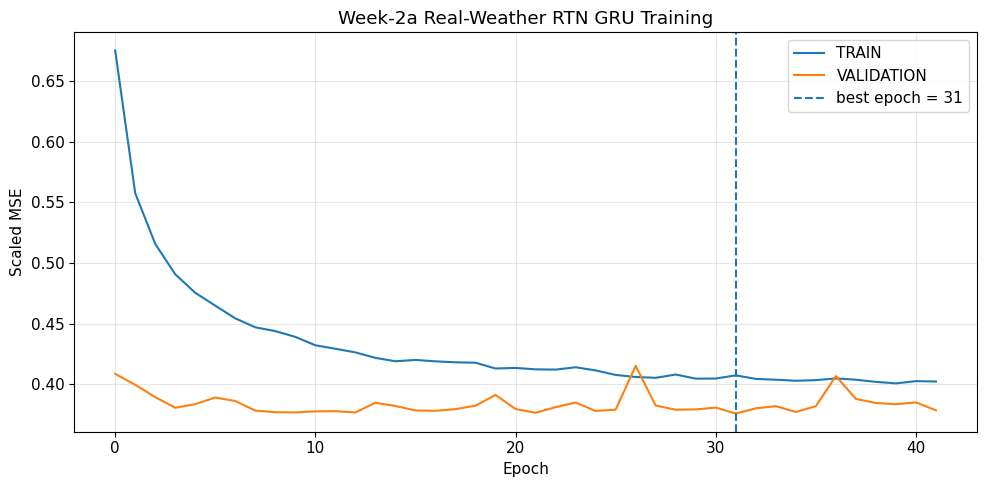

In [ ]:
# H2 — Training history plot

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    train_losses,
    label="TRAIN",
)

plt.plot(
    val_losses,
    label="VALIDATION",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=(
        f"best epoch = "
        f"{best_epoch}"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Scaled MSE"
)

plt.title(
    "Week-2a Real-Weather RTN GRU Training"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

TRAINING_PLOT = (
    OUTPUT_DIR
    / "week2a_GRU_training_history.png"
)

plt.savefig(
    TRAINING_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# 9 — Evaluate on held-out VALIDATION objects + 2024 weather

This is **not the final paper test**.

The validation population was absent from:
- GRU training
- feature/target scaler fitting

The 2024 weather histories were also absent from training.

All three methods are evaluated over the exact same post-warm-up sampled times:
- SGP4
- tuned EKF
- tuned EKF + GRU

In [ ]:
# I0 — Hybrid correction / RMSE helpers

def predict_rtn_corrections(
    sequence,
):

    X, _ = make_windows(
        sequence[
            "features"
        ],
        sequence[
            "targets_rtn"
        ],
    )

    Xs = scale_X(
        X
    )

    model.eval()

    with torch.no_grad():

        pred_scaled = (
            model(
                torch.tensor(
                    Xs,
                    dtype=torch.float32,
                ).to(
                    DEVICE
                )
            )
            .cpu()
            .numpy()
        )

    return (
        target_scaler
        .inverse_transform(
            pred_scaled
        )
    )


def rmse_positions(
    a,
    b,
):

    error = np.linalg.norm(
        a-b,
        axis=1,
    )

    return float(
        np.sqrt(
            np.mean(
                error**2
            )
        )
    )


print(
    "✅ Validation evaluation helpers defined"
)

✅ Validation evaluation helpers defined


In [ ]:
# I1 — Per-scenario held-out validation results

validation_rows = []


for seq in val_sequences:

    pred_rtn = (
        predict_rtn_corrections(
            seq
        )
    )

    start = SEQ_LEN

    est_states = (
        seq[
            "estimate_sampled"
        ][
            start:
        ]
    )

    truth_states = (
        seq[
            "truth_sampled"
        ][
            start:
        ]
    )

    sgp4_states = (
        seq[
            "sgp4_sampled"
        ][
            start:
        ]
    )

    corrected_positions = (
        est_states[
            :,
            :3,
        ].copy()
    )

    for j in range(
        len(
            corrected_positions
        )
    ):

        corrected_positions[
            j
        ] += rtn_to_eci(
            pred_rtn[
                j
            ],
            est_states[
                j
            ],
        )

    rmse_sgp4 = (
        rmse_positions(
            sgp4_states[
                :,
                :3,
            ],
            truth_states[
                :,
                :3,
            ],
        )
    )

    rmse_ekf = (
        rmse_positions(
            est_states[
                :,
                :3,
            ],
            truth_states[
                :,
                :3,
            ],
        )
    )

    rmse_hybrid = (
        rmse_positions(
            corrected_positions,
            truth_states[
                :,
                :3,
            ],
        )
    )

    metadata = seq[
        "metadata"
    ]

    validation_rows.append({
        **metadata,
        "rmse_sgp4_km":
        rmse_sgp4,
        "rmse_ekf_km":
        rmse_ekf,
        "rmse_hybrid_km":
        rmse_hybrid,
        "hybrid_gain_km":
        rmse_ekf
        - rmse_hybrid,
        "hybrid_improvement_pct":
        100.0
        * (
            1.0
            - rmse_hybrid
            / rmse_ekf
        ),
        "hybrid_better":
        rmse_hybrid
        < rmse_ekf,
    })


validation_results = pd.DataFrame(
    validation_rows
)

VALIDATION_RESULTS_PATH = (
    OUTPUT_DIR
    / "week2a_validation_results.csv"
)

validation_results.to_csv(
    VALIDATION_RESULTS_PATH,
    index=False,
)


display(
    validation_results.head(
        20
    )
)

print(
    "✅ Validation scenario results saved"
)

,name,norad,shell,day,weather_class,schedule,split,rmse_sgp4_km,rmse_ekf_km,rmse_hybrid_km,hybrid_gain_km,hybrid_improvement_pct,hybrid_better
0,STARLINK-30053,56700,43deg,2024-03-17,quiet,nominal_10min,VALIDATION,7.808864,0.293570,0.284424,0.009146,3.115462,True
1,STARLINK-30053,56700,43deg,2024-03-17,quiet,nominal_20min,VALIDATION,7.808864,0.378475,0.373255,0.005220,1.379276,True
2,STARLINK-30053,56700,43deg,2024-03-17,quiet,gap_4h,VALIDATION,7.808864,0.283881,0.310871,-0.026991,-9.507722,False
3,STARLINK-30053,56700,43deg,2024-04-22,moderate,nominal_10min,VALIDATION,14.550676,0.342790,0.315850,0.026940,7.858925,True
4,STARLINK-30053,56700,43deg,2024-04-22,moderate,nominal_20min,VALIDATION,14.550676,0.446646,0.440560,0.006087,1.362785,True
5,STARLINK-30053,56700,43deg,2024-04-22,moderate,gap_4h,VALIDATION,14.550676,0.412254,0.394242,0.018012,4.369052,True
6,STARLINK-30053,56700,43deg,2024-05-11,storm,nominal_10min,VALIDATION,28.036496,0.371229,0.281827,0.089402,24.082751,True
7,STARLINK-30053,56700,43deg,2024-05-11,storm,nominal_20min,VALIDATION,28.036496,0.506186,0.378562,0.127624,25.212842,True
8,STARLINK-30053,56700,43deg,2024-05-11,storm,gap_4h,VALIDATION,28.036496,0.617938,0.427354,0.190584,30.841887,True
9,STARLINK-38033,69739,97deg,2024-03-17,quiet,nominal_10min,VALIDATION,10.984172,0.256423,0.237584,0.018839,7.346962,True


✅ Validation scenario results saved


In [ ]:
# I2 — Overall paired validation statistics

mean_sgp4 = float(
    validation_results[
        "rmse_sgp4_km"
    ].mean()
)

mean_ekf = float(
    validation_results[
        "rmse_ekf_km"
    ].mean()
)

mean_hybrid = float(
    validation_results[
        "rmse_hybrid_km"
    ].mean()
)

paired_gain = (
    validation_results[
        "hybrid_gain_km"
    ]
    .to_numpy()
)

mean_gain = float(
    paired_gain.mean()
)

std_gain = float(
    paired_gain.std(
        ddof=1
    )
)

gain_ci95 = float(
    student_t.ppf(
        0.975,
        df=(
            len(
                paired_gain
            )
            - 1
        ),
    )
    * std_gain
    / np.sqrt(
        len(
            paired_gain
        )
    )
)

win_rate = float(
    validation_results[
        "hybrid_better"
    ].mean()
)

overall_improvement = (
    100.0
    * (
        1.0
        - mean_hybrid
        / mean_ekf
    )
)


print(
    "="*82
)

print(
    "WEEK-2A HELD-OUT VALIDATION — "
    "UNSEEN OBJECTS + UNSEEN 2024 WEATHER"
)

print(
    "="*82
)

print(
    f"SGP4 mean RMSE      : "
    f"{mean_sgp4:.3f} km"
)

print(
    f"Tuned EKF mean RMSE : "
    f"{mean_ekf:.3f} km"
)

print(
    f"Hybrid mean RMSE    : "
    f"{mean_hybrid:.3f} km"
)

print()

print(
    f"Overall Hybrid improvement "
    f"vs EKF: "
    f"{overall_improvement:.2f}%"
)

print(
    f"Mean paired gain: "
    f"{mean_gain:.3f} ± "
    f"{gain_ci95:.3f} km "
    f"(95% CI half-width)"
)

print(
    f"Hybrid win rate: "
    f"{win_rate:.1%}"
)

print(
    "="*82
)

WEEK-2A HELD-OUT VALIDATION — UNSEEN OBJECTS + UNSEEN 2024 WEATHER
SGP4 mean RMSE      : 32.308 km
Tuned EKF mean RMSE : 0.754 km
Hybrid mean RMSE    : 0.383 km

Overall Hybrid improvement vs EKF: 49.16%
Mean paired gain: 0.371 ± 0.158 km (95% CI half-width)
Hybrid win rate: 94.4%


In [ ]:
# I3 — Break down validation behavior by weather / observation schedule / shell

by_weather = (
    validation_results
    .groupby(
        "weather_class"
    )
    .agg(
        n=(
            "rmse_ekf_km",
            "size",
        ),
        ekf_mean_km=(
            "rmse_ekf_km",
            "mean",
        ),
        hybrid_mean_km=(
            "rmse_hybrid_km",
            "mean",
        ),
        gain_mean_km=(
            "hybrid_gain_km",
            "mean",
        ),
        improvement_pct=(
            "hybrid_improvement_pct",
            "mean",
        ),
        win_rate=(
            "hybrid_better",
            "mean",
        ),
    )
    .reset_index()
)


by_schedule = (
    validation_results
    .groupby(
        "schedule"
    )
    .agg(
        n=(
            "rmse_ekf_km",
            "size",
        ),
        ekf_mean_km=(
            "rmse_ekf_km",
            "mean",
        ),
        hybrid_mean_km=(
            "rmse_hybrid_km",
            "mean",
        ),
        gain_mean_km=(
            "hybrid_gain_km",
            "mean",
        ),
        improvement_pct=(
            "hybrid_improvement_pct",
            "mean",
        ),
        win_rate=(
            "hybrid_better",
            "mean",
        ),
    )
    .reset_index()
)


by_shell = (
    validation_results
    .groupby(
        "shell"
    )
    .agg(
        n=(
            "rmse_ekf_km",
            "size",
        ),
        ekf_mean_km=(
            "rmse_ekf_km",
            "mean",
        ),
        hybrid_mean_km=(
            "rmse_hybrid_km",
            "mean",
        ),
        gain_mean_km=(
            "hybrid_gain_km",
            "mean",
        ),
        improvement_pct=(
            "hybrid_improvement_pct",
            "mean",
        ),
        win_rate=(
            "hybrid_better",
            "mean",
        ),
    )
    .reset_index()
)


print(
    "\nBY WEATHER"
)
display(
    by_weather.round(4)
)

print(
    "\nBY OBSERVATION REGIME"
)
display(
    by_schedule.round(4)
)

print(
    "\nBY ORBITAL SHELL"
)
display(
    by_shell.round(4)
)


by_weather.to_csv(
    OUTPUT_DIR
    / "week2a_validation_by_weather.csv",
    index=False,
)

by_schedule.to_csv(
    OUTPUT_DIR
    / "week2a_validation_by_schedule.csv",
    index=False,
)

by_shell.to_csv(
    OUTPUT_DIR
    / "week2a_validation_by_shell.csv",
    index=False,
)


BY WEATHER


,weather_class,n,ekf_mean_km,hybrid_mean_km,gain_mean_km,improvement_pct,win_rate
0,moderate,18,0.6884,0.3666,0.3218,31.8228,1.0000
1,quiet,18,0.4660,0.3222,0.1438,19.5303,0.8333
2,storm,18,1.1080,0.4614,0.6466,46.4384,1.0000



BY OBSERVATION REGIME


,schedule,n,ekf_mean_km,hybrid_mean_km,gain_mean_km,improvement_pct,win_rate
0,gap_4h,18,1.1586,0.4596,0.6989,45.3657,0.9444
1,nominal_10min,18,0.4616,0.2910,0.1706,25.8094,0.9444
2,nominal_20min,18,0.6423,0.3997,0.2427,26.6163,0.9444



BY ORBITAL SHELL


,shell,n,ekf_mean_km,hybrid_mean_km,gain_mean_km,improvement_pct,win_rate
0,43deg,27,0.9779,0.4265,0.5514,39.1936,0.9630
1,53deg,9,0.4976,0.3419,0.1556,21.1841,0.7778
2,97deg,18,0.5469,0.3395,0.2074,28.4090,1.0000


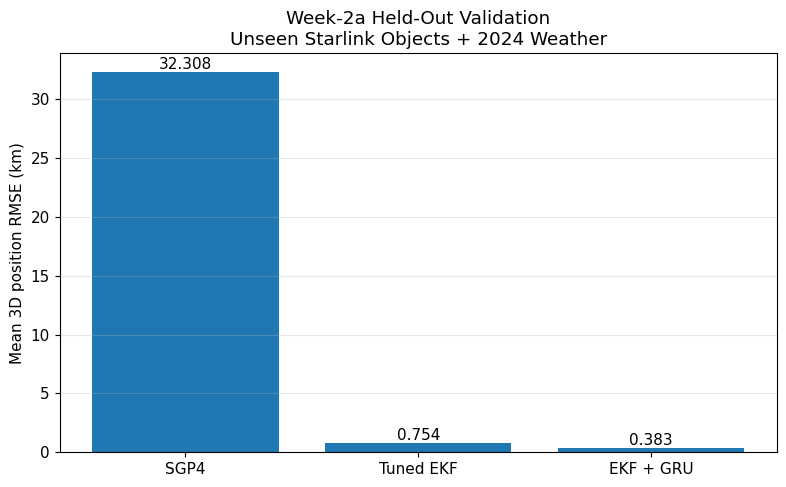

In [ ]:
# I4 — Validation comparison figure

labels = [
    "SGP4",
    "Tuned EKF",
    "EKF + GRU",
]

values = [
    mean_sgp4,
    mean_ekf,
    mean_hybrid,
]

plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    values,
)

plt.ylabel(
    "Mean 3D position RMSE (km)"
)

plt.title(
    "Week-2a Held-Out Validation\n"
    "Unseen Starlink Objects + 2024 Weather"
)

plt.grid(
    axis="y",
    alpha=0.3,
)

for bar, value in zip(
    bars,
    values,
):

    plt.text(
        bar.get_x()
        + bar.get_width()/2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

VALIDATION_PLOT = (
    OUTPUT_DIR
    / "week2a_validation_mean_RMSE.png"
)

plt.savefig(
    VALIDATION_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# ✅ WEEK-2A STOP POINT

Do **not** access the six TEST objects or calendar year 2025 yet.

At this point we have a legitimate model-development answer based on:

- 18 TRAIN Starlink objects;
- 2021–2023 real historical weather;
- 6 VALIDATION Starlink objects;
- separate 2024 weather;
- physical NRLMSISE-00 drag forcing;
- tuned fixed-Q EKF;
- multiple observation regimes;
- leakage-safe RTN GRU training.

## Decision after inspecting validation

### If GRU clearly improves the tuned EKF
Freeze:
- feature set
- architecture
- sequence length
- scalers
- weights
- Q
- observation-regime definitions

Then build the final-test notebook using:
- six untouched TEST objects
- previously untouched 2025 weather

### If improvement is strongly regime-dependent
A conditional/gated hybrid may be considered using **validation only**, but that decision must be frozen before final testing.

### If GRU does not improve
Do not repeatedly retune against validation until it wins. We would diagnose whether the physical residual contains learnable temporal structure and decide whether one pre-declared model modification is scientifically justified.

In [ ]:
# J0 — Reproducibility manifest

manifest = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "source_bundle": (
        EXPECTED_ZIP.name
    ),
    "n_train_objects": int(
        len(
            TRAIN_OBJECTS
        )
    ),
    "n_validation_objects": int(
        len(
            VAL_OBJECTS
        )
    ),
    "n_test_objects_protected": int(
        len(
            TEST_OBJECT_IDS
        )
    ),
    "test_objects_used": False,
    "training_weather_years": (
        "2021-2023"
    ),
    "validation_weather_year": (
        "2024"
    ),
    "reserved_final_weather_year": (
        "2025"
    ),
    "weather_2025_queried": False,
    "train_weather_days": {
        key: [
            str(
                day.date()
            )
            for day in days
        ]
        for key, days
        in TRAIN_WEATHER_DAYS.items()
    },
    "validation_weather_days": {
        key: [
            str(
                day.date()
            )
            for day in days
        ]
        for key, days
        in VAL_WEATHER_DAYS.items()
    },
    "duration_hours": (
        DURATION_HOURS
    ),
    "dynamics_dt_seconds": (
        DYN_DT
    ),
    "density_step_minutes": (
        DENSITY_STEP_MIN
    ),
    "ml_sample_minutes": (
        ML_SAMPLE_MIN
    ),
    "gru_history_minutes": (
        SEQ_LEN
        * ML_SAMPLE_MIN
    ),
    "sigma_a_km_s2": (
        SIGMA_A_FINAL_DEV
    ),
    "drag_coefficient": (
        DRAG_COEFFICIENT
    ),
    "area_to_mass_m2_kg": (
        AREA_TO_MASS_M2_KG
    ),
    "observation_schedules": (
        OBS_SCHEDULES
    ),
    "feature_names": (
        FEATURE_NAMES
    ),
    "hidden_size": (
        HIDDEN_SIZE
    ),
    "dropout": (
        DROPOUT
    ),
    "best_epoch": (
        int(
            best_epoch
        )
    ),
    "best_validation_scaled_mse": (
        float(
            best_val
        )
    ),
    "validation_mean_rmse": {
        "sgp4_km": (
            mean_sgp4
        ),
        "ekf_km": (
            mean_ekf
        ),
        "hybrid_km": (
            mean_hybrid
        ),
    },
    "validation_hybrid_improvement_pct": (
        overall_improvement
    ),
    "validation_paired_gain_km": (
        mean_gain
    ),
    "validation_paired_gain_ci95_halfwidth_km": (
        gain_ci95
    ),
    "validation_win_rate": (
        win_rate
    ),
}

MANIFEST_PATH = (
    ROOT_DIR
    / "week2a_reproducibility_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


print(
    "✅ Week-2a manifest saved"
)
print(
    "   ",
    MANIFEST_PATH,
)

✅ Week-2a manifest saved
    /content/IAC2026_FINAL_WEEK2A/week2a_reproducibility_manifest.json


In [ ]:
# J1 — List saved outputs

print(
    "Week-2a saved files:"
)

for path in sorted(
    ROOT_DIR.rglob("*")
):

    if path.is_file():

        print(
            "  -",
            path.relative_to(
                ROOT_DIR
            ),
        )

Week-2a saved files:
  - data/week2a_scenario_metadata.csv
  - data/week2a_skipped_truth_cases.csv
  - data/week2a_weather_split.csv
  - model/week2a_RTN_GRU.pt
  - model/week2a_feature_scaler.joblib
  - model/week2a_target_scaler.joblib
  - outputs/week2a_GRU_training_history.png
  - outputs/week2a_validation_by_schedule.csv
  - outputs/week2a_validation_by_shell.csv
  - outputs/week2a_validation_by_weather.csv
  - outputs/week2a_validation_mean_RMSE.png
  - outputs/week2a_validation_results.csv
  - week1b_source/data/real_space_weather_daily_activity_scan.csv
  - week1b_source/data/starlink_30_object_cohort_WEEK1B.csv
  - week1b_source/outputs/real_MSIS_density_demo.png
  - week1b_source/outputs/real_MSIS_density_summary.csv
  - week1b_source/outputs/real_historical_F107_Ap_profiles.png
  - week1b_source/outputs/real_weather_Q_calibration.png
  - week1b_source/outputs/real_weather_Q_sweep_TRAIN.csv
  - week1b_source/outputs/real_weather_Q_sweep_VALIDATION.csv
  - week1b_source/output

# Optional — Download complete Week-2a bundle

After the notebook finishes successfully, change:

`DOWNLOAD_WEEK2A_BUNDLE = False`

to:

`DOWNLOAD_WEEK2A_BUNDLE = True`

and run the final cell once.

Also download the executed `.ipynb`.

In [ ]:
# J2 — OPTIONAL archive/download

DOWNLOAD_WEEK2A_BUNDLE = True

if DOWNLOAD_WEEK2A_BUNDLE:

    archive_base = (
        "/content/"
        "IAC2026_FINAL_WEEK2A_bundle"
    )

    shutil.make_archive(
        archive_base,
        "zip",
        ROOT_DIR,
    )

    archive_path = (
        archive_base
        + ".zip"
    )

    print(
        "✅ Archive created:",
        archive_path,
    )

    from google.colab import files

    files.download(
        archive_path
    )

else:

    print(
        "DOWNLOAD_WEEK2A_BUNDLE is False."
    )

    print(
        "Set it to True only after "
        "the development run is complete."
    )

✅ Archive created: /content/IAC2026_FINAL_WEEK2A_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>